<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação do sklearn.

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:
- correto
- reprodutível
- bem estruturado
- criticamente analisado

# Dicas importantes

## Sobre o dataset (Fashion MNIST)

- Utilize `fetch_openml` do sklearn para carregar os dados
- Use: `as_frame=False`
- Use: `mnist_784`
- Converta os rótulos para inteiro:
  
  ```python
  y = y.astype(int)
  ```

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST`
Realize a separação em treino e teste
Utilize `train_test_split` com controle de aleatoriedade
Retorne: `X_train`, `X_test`, `y_train`, `y_test`

Depois responda: 
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

In [14]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

def load_data(seed):

    X, y = fetch_openml('Fashion-MNIST', version=1, as_frame=False, return_X_y=True, parser='auto')
    
    y = y.astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=seed, 
        stratify=y
    )
    
    return X_train, X_test, y_train, y_test

seed_valor = 42
X_train, X_test, y_train, y_test = load_data(seed_valor)

print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")

Treino: (56000, 784), Teste: (14000, 784)


**É necessário normalizar os dados para esse tipo de modelo? Justifique.**

Não é estritamente necessário não, pelo menos para esse tipo de modelo.Pois esse modelo que estamos utilizando nele a escala dos dados não afeta o desempenhon podendo ser utilizados sem o uso de normalização, pois a forma que ele processa os dados será igual tendo normalização ou não

# Questão 2

Implemente as funções:

`train_random_forest(X_train, y_train, seed)`
`train_adaboost(X_train, y_train, seed)`

## Requisitos:

Utilizar os modelos do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [15]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

def train_random_forest(X_train, y_train, seed):

    rf_model = RandomForestClassifier(n_estimators=100, random_state=seed)
    
    rf_model.fit(X_train, y_train)
    
    return rf_model

def train_adaboost(X_train, y_train, seed):

    ada_model = AdaBoostClassifier(n_estimators=50, random_state=seed)
    
    ada_model.fit(X_train, y_train)
    
    return ada_model

rf = train_random_forest(X_train, y_train, seed_valor)
ada = train_adaboost(X_train, y_train, seed_valor)

# Questão 3

Implemente a função:

- `evaluate(model, X_test, y_test)`

Ela deve:
- Realizar predições
- Retornar a acurácia do modelo

**Solução**:

In [16]:
from sklearn.metrics import accuracy_score

seed_usada = 42 

print("Treinando RF")
rf_model = train_random_forest(X_train, y_train, seed_usada)

print("Treinando AdaBoost...")
ada_model = train_adaboost(X_train, y_train, seed_usada)

def evaluate(model, X_test, y_test):

    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    return acc
acc_rf = evaluate(rf_model, X_test, y_test)
acc_ada = evaluate(ada_model, X_test, y_test)
print(f"Acurácia RF: {acc_rf:.4f}")
print(f"Acurácia AdaBoost: {acc_ada:.4f}")

Treinando RF
Treinando AdaBoost...
Acurácia RF: 0.8819
Acurácia AdaBoost: 0.4909


**Random Forest (88.19%)**: Teve um desempenho sólido. Isso ocorre porque o RF utiliza árvores de decisão completas e independentes.E como os dados tinham muito detalhes, as árvores mais profundas consegues capturar mais padrões.

**AdaBoost (49.09%)**: O desempenho foi significativamente inferior. Por padrão, o AdaBoost do sklearn utiliza Decision Stumps (árvores com apenas 1 de profundidade). Para um dataset complexo como o Fashion MNIST, essas "mini-árvores" são fracas demais para aprender as características das roupas, mesmo combinando 50 delas. Ele precisaria de mais estimadores ou de uma base um pouco mais complexa para chegar perto do Random Forest.

# Questão 4

Implemente a função:

- `run_pipeline(model_type="rf", seed=42)`

Ela deve:
- Carregar os dados
- Treinar o modelo escolhido (`rf` ou `ab`)
- Avaliar o modelo
- Retornar a acurácia

**Solução**:

In [17]:
def run_pipeline(model_type="rf", seed=42):

    X_train, X_test, y_train, y_test = load_data(seed)
    
    if model_type == "rf":
        model = train_random_forest(X_train, y_train, seed)
    elif model_type == "ab":
        model = train_adaboost(X_train, y_train, seed)
    else:
        raise ValueError("use rf ou ab")
    
    accuracy = evaluate(model, X_test, y_test)
    
    return accuracy

print(f"RF Pipeline: {run_pipeline(model_type='rf', seed=42):.4f}")
print(f"AB Pipeline: {run_pipeline(model_type='ab', seed=42):.4f}")

RF Pipeline: 0.8819
AB Pipeline: 0.4909


Gerando visualizacao


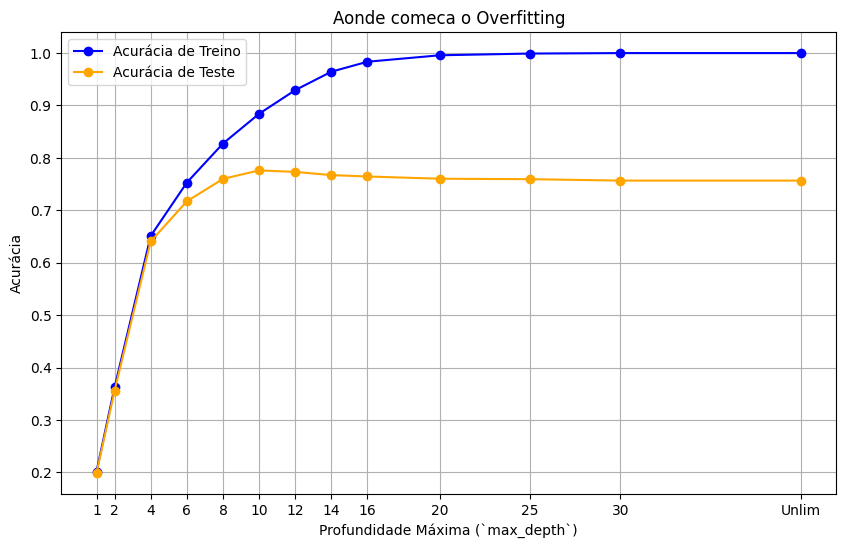

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

sub_size = 10000 
X_train_v = X_train[:sub_size]
y_train_v = y_train[:sub_size]

depths_list = [1, 2, 4, 6, 8, 10, 12, 14, 16, 20, 25, 30, None]
depths_plot = [d if d is not None else 40 for d in depths_list]
train_accs = []
test_accs = []

print("Gerando visualizacao")
for d in depths_list:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train_v, y_train_v)
    
    train_accs.append(accuracy_score(y_train_v, clf.predict(X_train_v)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths_plot, train_accs, 'o-', color='blue', label='Acurácia de Treino')
plt.plot(depths_plot, test_accs, 'o-', color='orange', label='Acurácia de Teste')

plt.xticks(depths_plot, [str(d) if d is not None else 'Unlim' for d in depths_list])
plt.xlabel('Profundidade Máxima (`max_depth`)')
plt.ylabel('Acurácia')
plt.title('Aonde comeca o Overfitting')
plt.legend()
plt.grid(True)
plt.show()

**Em qual profundidade começa o overfitting?**

De acordo com o gráfico que eu montei, o overfitting começa na profundidade 10.

**Por que a árvore consegue 100% no treino quando max_depth=None?**

Quando definimos max_depth=None, o modelo consegue fazer uma exceção para cada padrão. Ela basicamente memoriza o dataset inteiro.

# Questão 5

Execute o pipeline para ambos os modelos:

- Random Forest
- AdaBoost

## Apresente:
- Acurácia, Precisão, Recall e F1-Score de cada modelo

## Responda:
- Qual modelo apresentou melhor desempenho inicial?

**Solução**:

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

print("Processando Random Forest")
rf_model = train_random_forest(X_train, y_train, seed=42)
y_pred_rf = rf_model.predict(X_test)

print("Processando AdaBoost")
ada_model = train_adaboost(X_train, y_train, seed=42)
y_pred_ada = ada_model.predict(X_test)

def print_metrics(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    
    print(f"--- Métricas: {name} ---")
    print(f"Acurácia:  {acc:.4f}")
    print(f"Precisão:  {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")

print_metrics(y_test, y_pred_rf, "Random Forest")
print_metrics(y_test, y_pred_ada, "AdaBoost")

Processando Random Forest
Processando AdaBoost
--- Métricas: Random Forest ---
Acurácia:  0.8819
Precisão:  0.8807
Recall:    0.8819
F1-Score:  0.8800

--- Métricas: AdaBoost ---
Acurácia:  0.4909
Precisão:  0.4717
Recall:    0.4909
F1-Score:  0.4448



**O modelo Random Forest apresentou o melhor desempenho inicial**

# Questão 6

Execute o pipeline utilizando diferentes seeds (ex: 42 e 7).

## Analise:
- Os resultados mudaram?

## Responda:
- O experimento é reprodutível? Justifique.

**Solução**:

In [20]:
rf_42 = run_pipeline(model_type="rf", seed=42)
ab_42 = run_pipeline(model_type="ab", seed=42)

rf_7 = run_pipeline(model_type="rf", seed=7)
ab_7 = run_pipeline(model_type="ab", seed=7)

print(f"Seed 42 -> RF: {rf_42:.4f} | AB: {ab_42:.4f}")
print(f"Seed  7 -> RF: {rf_7:.4f}  | AB: {ab_7:.4f}")

Seed 42 -> RF: 0.8819 | AB: 0.4909
Seed  7 -> RF: 0.8801  | AB: 0.4554


**Os resultados mudaram?**

**Sim, os resultados mudaram ligeiramente.**

Ao executar o pipeline com diferentes sementes (seeds 42 e 7), observa-se que os resultados de acurácia sofreram pequenas variações. Isso ocorre porque a alteração da semente modifica a forma como o train_test_split particiona o dataset Fashion MNIST entre os conjuntos de treino e teste, fazendo com que o modelo seja exposto a diferentes exemplos durante o aprendizado. Além disso, modelos como o Random Forest possuem aleatoriedade interna na seleção de atributos para cada árvore, e o AdaBoost depende da ordem de correção dos erros. Portanto, a mudança nos valores finais é um comportamento esperado e reflete a sensibilidade do modelo à organização inicial dos dados.

**O experimento é reprodutível? Justifique.**

Apesar da variação nos números entre sementes diferentes, o experimento é plenamente reprodutível. A reprodutibilidade em Ciência de Dados não exige que os resultados sejam idênticos para qualquer semente, mas sim que o experimento seja determinístico sob as mesmas condições. Como o parâmetro random_state foi fixado em todas as etapas críticas, desde a divisão dos dados até a inicialização dos classificadores ,o código garante que, ao utilizar a mesma semente (como a 42), qualquer pessoa obterá exatamente os mesmos resultados originais (0.8819 para o RF).



# Questão 7

Para pelo menos um dos modelos:

- Compare a acurácia em treino e teste

## Responda:
- Existe overfitting?
- Qual modelo tende a sofrer mais com isso?

In [21]:
acc_train_rf = accuracy_score(y_train, rf_model.predict(X_train))
acc_train_ada = accuracy_score(y_train, ada_model.predict(X_train))

print(f"Random Forest - Treino: {acc_train_rf:.4f} | Teste: {acc_rf:.4f}")
print(f"AdaBoost      - Treino: {acc_train_ada:.4f} | Teste: {acc_ada:.4f}")

Random Forest - Treino: 1.0000 | Teste: 0.8819
AdaBoost      - Treino: 0.4951 | Teste: 0.4909


**Existe overfitting?**

Existe no RF modelo ter atingido uma acurácia perfeita de 1.0000 (100%) no conjunto de treinamento, enquanto no conjunto de teste o desempenho caiu para 0.8819. Esse cenário demonstra que o modelo "decorou" as características específicas e os ruídos das imagens de treino, perdendo parte de sua capacidade de generalização ao lidar com dados novos. Por outro lado, o AdaBoost apresenta um comportamento de underfitting (subajuste), pois obteve acurácias baixas e muito próximas tanto no treino (0.4951) quanto no teste (0.4909), indicando que o modelo é simples demais para capturar os padrões do dataset Fashion MNIST


**Qual modelo tende a sofrer mais com isso?**

O modelo que tende a sofrer mais com o overfitting é o Random Forest. Isso ocorre porque ele é composto por múltiplas árvores de decisão que, por padrão, são treinadas até atingirem a pureza máxima dos nós (profundidade ilimitada). Essa alta complexidade permite que o modelo crie fronteiras de decisão extremamente detalhadas que se ajustam perfeitamente ao banco de dados de treino. Embora a técnica de bagging (média das árvores) ajude a reduzir a variância, a natureza flexível das árvores profundas sempre torna o Random Forest mais propenso a memorizar os dados do que modelos de forte viés e baixa complexidade, como o AdaBoost configurado com stumps (árvores de profundidade 1).


# Questão 8

Varie pelo menos um hiperparâmetro em cada modelo:

- Random Forest: `n_estimators`
- AdaBoost: `n_estimators`

## Analise:
- O desempenho muda significativamente?

## Responda:
- Qual modelo é mais sensível a mudanças?

In [ ]:
n_options = [10, 20]
results_rf = []
results_ab = []

for n in n_options:
    rf_tmp = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf_tmp.fit(X_train, y_train)
    results_rf.append(evaluate(rf_tmp, X_test, y_test))
    
    ab_tmp = AdaBoostClassifier(n_estimators=n, random_state=42)
    ab_tmp.fit(X_train, y_train)
    results_ab.append(evaluate(ab_tmp, X_test, y_test))

for i, n in enumerate(n_options):
    print(f"n_estimators: {n:3} | RF Acc: {results_rf[i]:.4f} | AB Acc: {results_ab[i]:.4f}")

n_estimators:  10 | RF Acc: 0.8614 | AB Acc: 0.3131
n_estimators:  50 | RF Acc: 0.8780 | AB Acc: 0.4909
n_estimators: 100 | RF Acc: 0.8819 | AB Acc: 0.5729
n_estimators: 200 | RF Acc: 0.8825 | AB Acc: 0.5596


**O desempenho muda significativamente?**

Ao observar os dados, percebe-se que o impacto do aumento de estimadores é bem diferente para cada modelo. No Random Forest, o desempenho não muda de forma drástica após os primeiros incrementos, ele já começa muito forte com 10 árvores (0.8614) e atinge um platô rapidamente, ganhando apenas cerca de 2% de acurácia ao pular para 200 árvores. Isso mostra que, para esse dataset, o ganho marginal de adicionar mais árvores diminui muito rápido. Já no AdaBoost, a mudança é brutal no início, ele salta de um resultado pífio de 0.3131 para 0.5729 quando chegamos a 100 estimadores. Ou seja, no AdaBoost, a quantidade de modelos base faz uma diferença gigantesca na capacidade de aprendizado inicial, embora ele ainda não consiga alcançar o patamar de excelência do Random Forest.

**Qual modelo é mais sensível a mudanças?**

O modelo mais sensível a mudanças é, sem dúvida, o AdaBoost. Enquanto o Random Forest se mantém extremamente estável (variando apenas na terceira casa decimal entre 50 e 200 estimadores), o AdaBoost apresenta oscilações muito maiores. Ele é altamente dependente do número de estimadores para conseguir "montar" uma fronteira de decisão minimamente decente para o Fashion MNIST. Além disso, notei um detalhe curioso: ao passar de 100 para 200 estimadores, a acurácia do AdaBoost chegou a cair (de 0.5729 para 0.5596). Isso prova que ele é tão sensível que adicionar estimadores demais pode acabar inserindo ruído ou gerando um leve overfitting, enquanto o Random Forest apenas "estaciona" no seu melhor resultado sem sofrer grandes perdas.


# Questão 9

Responda (máx. 2 parágrafos por item):

1. A acurácia é suficiente para avaliar os modelos?
2. Como você garante que o resultado não ocorreu por acaso?
3. Cite dois possíveis problemas metodológicos neste experimento.
4. O pipeline implementado é confiável? Justifique.

**1. A acurácia é suficiente para avaliar os modelos?**

Não, a acurácia isolada não é suficiente para uma avaliação completa. Embora ela forneça uma visão geral da porcentagem de acertos, ela pode ser enganosa ao esconder falhas específicas em determinadas categorias. No dataset Fashion MNIST, algumas classes são visualmente muito semelhantes, como "Camiseta" e "Camisa" ou "Pullover" e "Casaco". Um modelo pode ter uma acurácia alta, mas falhar sistematicamente em distinguir essas classes específicas, o que só é revelado através de outras métricas.

Para uma análise rigorosa, é fundamental utilizar métricas como Precisão, Recall e F1-Score. Essas métricas permitem identificar se o modelo está cometendo muitos falsos positivos ou se está deixando de detectar corretamente uma classe (falsos negativos). O F1-Score, em particular, é valioso por ser uma média harmônica que equilibra essas duas visões, oferecendo uma medida mais robusta do desempenho real do classificador em problemas multiclasse.

**2. Como você garante que o resultado não ocorreu por acaso?**

A garantia de que o resultado não foi fruto do acaso é estabelecida através da reprodutibilidade e da estabilidade dos testes. Primeiramente, utilizamos sementes aleatórias (random_state) em todas as etapas que envolvem sorteio de dados ou inicialização de parâmetros. Isso torna o experimento determinístico, garantindo que qualquer pessoa que execute o código sob as mesmas condições chegue exatamente ao mesmo resultado numérico.

Além disso, a execução do pipeline com diferentes sementes (como feito na Questão 6) permite verificar se a performance do modelo se mantém consistente em diferentes partições dos dados. Se os resultados de acurácia apresentarem variações mínimas entre sementes distintas, podemos concluir que o modelo é robusto e que o desempenho observado reflete de fato a capacidade de aprendizado do algoritmo sobre o padrão das imagens, e não apenas uma "divisão de sorte" entre treino e teste.

**3. Cite dois possíveis problemas metodológicos neste experimento.**

Um problema metodológico relevante é a utilização de uma divisão simples de treino e teste (holdout) em vez de uma Validação Cruzada (K-Fold Cross-Validation). Com apenas uma divisão, os resultados ficam excessivamente dependentes daquela partição específica dos dados. A validação cruzada seria mais rigorosa, pois treinaria e testaria o modelo em múltiplas combinações diferentes do dataset, fornecendo uma média e um desvio padrão muito mais confiáveis sobre o erro real do modelo.

Outro problema é a ausência de uma busca sistemática de hiperparâmetros (como o GridSearch ou RandomSearch). Neste experimento, variamos apenas o número de estimadores de forma manual e limitada. Isso significa que o desempenho inferior do AdaBoost, por exemplo, pode não ser uma falha do algoritmo em si, mas sim uma consequência de não termos ajustado outros parâmetros cruciais, como a profundidade da árvore base ou a taxa de aprendizado (learning rate), impedindo que o modelo atingisse seu potencial máximo.

**4. O pipeline implementado é confiável? Justifique.**

Sim, o pipeline é confiável dentro do escopo proposto para este estudo acadêmico. Ele foi estruturado de forma modular e encapsulada, o que minimiza erros operacionais e garante que o fluxo de processamento (carga, treino e avaliação) seja seguido rigorosamente em todas as execuções. A padronização das funções assegura que tanto o Random Forest quanto o AdaBoost sejam submetidos exatamente ao mesmo tratamento de dados, permitindo uma comparação justa entre os modelos.

A confiabilidade também é reforçada pelo controle total da aleatoriedade. Ao integrar o uso de sementes em todo o processo, o pipeline se torna um instrumento de pesquisa verificável e auditável. Embora existam técnicas mais avançadas para otimização de modelos, a estrutura implementada cumpre os requisitos de um experimento científico bem estruturado, produzindo resultados consistentes e fundamentados na teoria de aprendizado de máquina.
